# Kennicutt-Schmidt relation across all galaxies

Loads all extracted `.npz` snapshots per galaxy, joins them, and plots the
pixel-level KS relation (gas surface density vs. SFR surface density) in
five horizontal panels with the Kennicutt (1998) / SH03 line overlaid.

In [ ]:
import sys
from pathlib import Path

project_root = str(Path.cwd().parent) if Path.cwd().name == "notebooks" else str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt

from sfemulator.data.loader import (
    load_all_galaxies,
    SURFDENS_TO_MSUN_PC2, SFR_SURFDENS_TO_MSUN_YR_KPC2,
)

In [ ]:
SNAP_DIR = Path("../snapshots")
data = load_all_galaxies(SNAP_DIR)

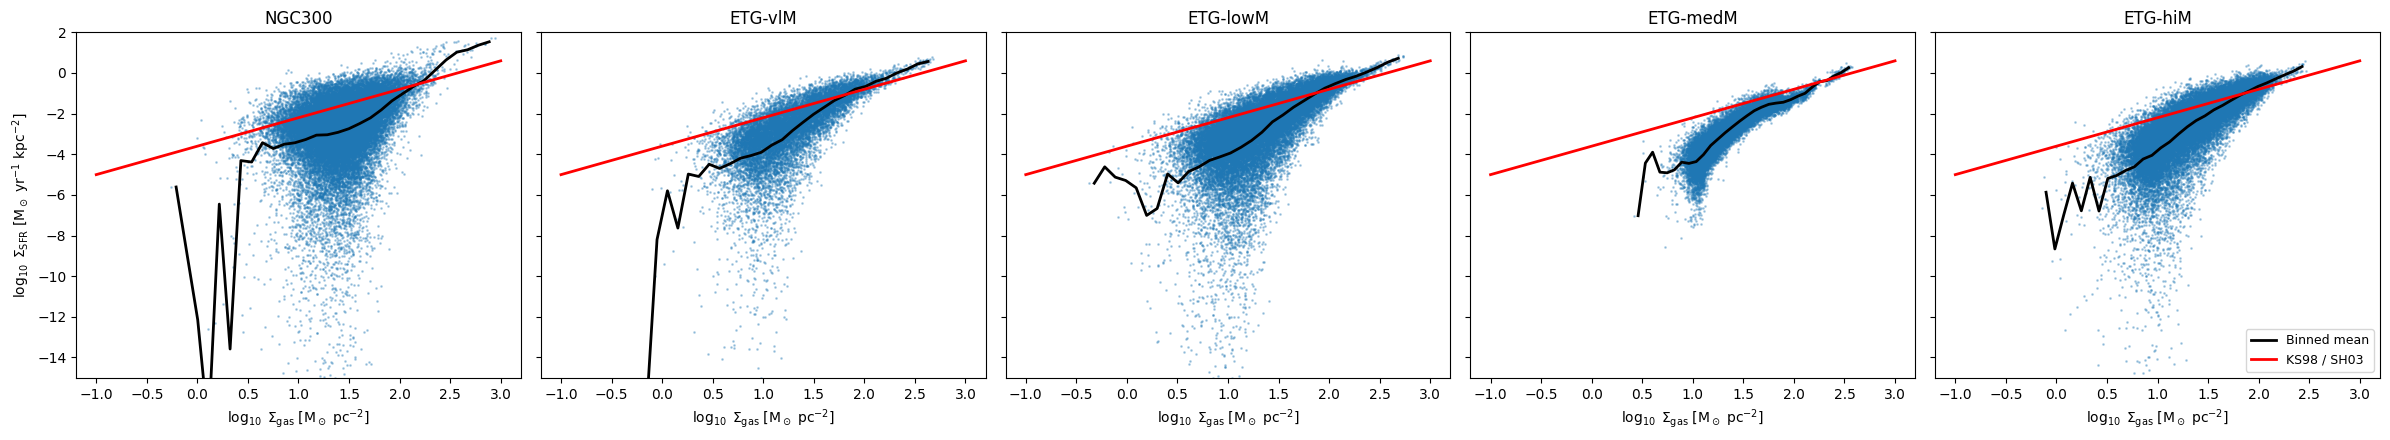

In [6]:
# KS98 line
sig_gas_ks = np.logspace(-1, 3, 200)
sig_sfr_ks = 2.5e-4 * sig_gas_ks**1.4

fig, axes = plt.subplots(1, 5, figsize=(24, 4.5), sharey=True)

for ax, (name, (gas, sfr)) in zip(axes, data.items()):
    log_gas = np.log10(gas)
    log_sfr = np.log10(sfr)

    ax.scatter(log_gas, log_sfr, s=1, alpha=0.3)

    # Binned mean
    bin_edges = np.linspace(log_gas.min(), log_gas.max(), 31)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    bin_means = np.full(30, np.nan)
    for i in range(30):
        in_bin = (log_gas >= bin_edges[i]) & (log_gas < bin_edges[i + 1])
        if in_bin.sum() > 0:
            bin_means[i] = np.mean(log_sfr[in_bin])
    valid = np.isfinite(bin_means)
    ax.plot(bin_centers[valid], bin_means[valid], "k-", lw=2, label="Binned mean")

    ax.plot(np.log10(sig_gas_ks), np.log10(sig_sfr_ks), "r-", lw=2, label="KS98 / SH03")

    ax.set_title(name)
    ax.set_xlabel(r"$\log_{10}\;\Sigma_{\rm gas}$ [M$_\odot$ pc$^{-2}$]")

axes[0].set_ylim([-15., 2.])
axes[0].set_ylabel(r"$\log_{10}\;\Sigma_{\rm SFR}$ [M$_\odot$ yr$^{-1}$ kpc$^{-2}$]")
axes[-1].legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()